In [1]:
import numpy as np
import pandas as pd
import sys
from pathlib import Path as P
r = P.cwd() if (P.cwd() / "src").exists() else P.cwd().parent
sys.path[:0] = [str(r / "src"), str(r)]
from simulation_scripts.execute_simulations import *
from retrieval_methods.umpa_retrieval import *


# Load Simulation Parameters

In [2]:
param_card_dict = np.load("../data/param_cards/Param_Card_GBI_Mono.npy", allow_pickle=True)

pd.DataFrame(param_card_dict.item().items(), columns=["Parameter", "Value"])

,Parameter,Value
0,Type of spectrum,Mono
1,Source geometry,Parallel
2,Energy (keV),20
3,Focal spot size (μm),1
4,Sim. pixel (μm),1
5,FOV (pix),"(300,300)"
6,Num. events per pixel,1000
7,Binning factor,10
8,FWHM PSF (pix),2
9,Period in X (μm),7


# Calculate Reference Image

Obtaining reference and sample images for Energy = 21.0 keV


100%|██████████| 1/1 [00:01<00:00,  1.68s/it]


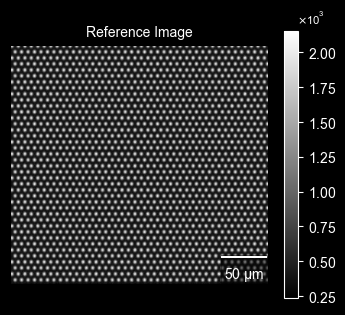

In [3]:
show_reference_GBI(param_card_dict.item())

# Save Reference (Flat-Field) and Sample Images 

In [4]:
run_GBI_sim(param_card_dict.item(), save_path="../results/GBI_Mono/")

Running simulation...
Obtaining reference and sample images for Energy = 20.0 keV


100%|██████████| 25/25 [00:39<00:00,  1.56s/it]


Simulation finished.


# Retrieve and Plot Transmission Image

(25, 260, 260)


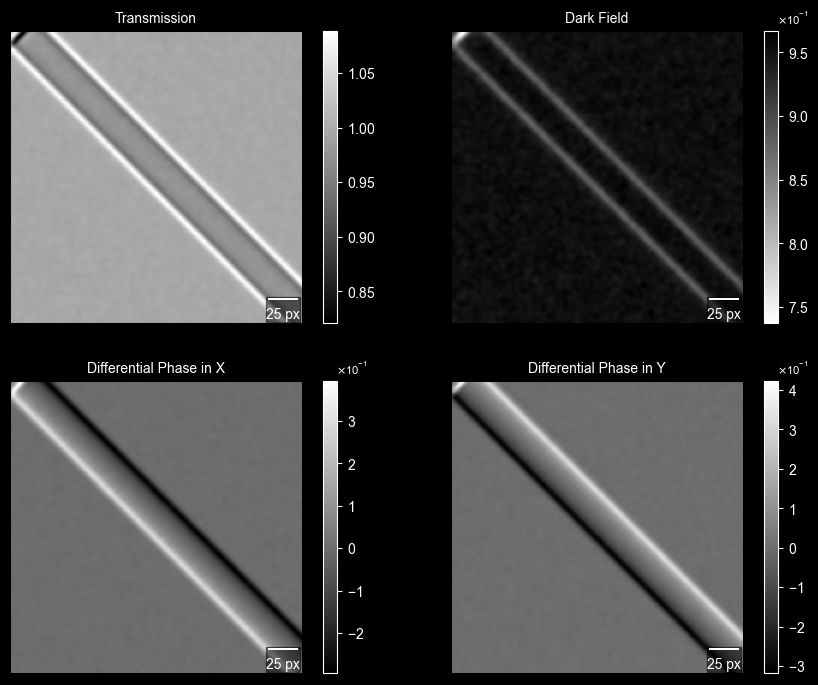

In [6]:
Iref = np.load("../results/GBI_Mono/I_refs_poly.npy")
Isamp = np.load("../results/GBI_Mono/I_samps_poly.npy")
params = {"Nw": 4, "max_shift": 4, "df_bool": True}
get_retrieved_images(Iref, Isamp, params)